In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from keras.models import Sequential
from keras.layers import Dense

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
# Load dataset
df = pd.read_csv("./data/car_price_prediction_raw_train.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (19237, 18)


In [3]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [4]:
# Check all columns
print(df.columns.tolist())
print("\nTotal columns:", len(df.columns))

['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year', 'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage', 'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color', 'Airbags']

Total columns: 18


In [5]:
df.describe(include="all")

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
count,1.923700e+04,1.923700e+04,19237,19237,19237,19237.000000,19237,19237,19237,19237,19237,19237.000000,19237,19237,19237,19237,19237,19237.000000
unique,NaN,NaN,559,65,1590,NaN,11,2,7,107,7687,NaN,4,3,3,2,16,NaN
top,NaN,NaN,-,HYUNDAI,Prius,NaN,Sedan,Yes,Petrol,2,0 km,NaN,Automatic,Front,04-May,Left wheel,Black,NaN
freq,NaN,NaN,5819,3769,1083,NaN,8736,13954,10150,3916,721,NaN,13514,12874,18332,17753,5033,NaN
mean,4.557654e+07,1.855593e+04,NaN,NaN,NaN,2010.912824,NaN,NaN,NaN,NaN,NaN,4.582991,NaN,NaN,NaN,NaN,NaN,6.582627
std,9.365914e+05,1.905813e+05,NaN,NaN,NaN,5.668673,NaN,NaN,NaN,NaN,NaN,1.199933,NaN,NaN,NaN,NaN,NaN,4.320168
min,2.074688e+07,1.000000e+00,NaN,NaN,NaN,1939.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4.569837e+07,5.331000e+03,NaN,NaN,NaN,2009.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,4.577231e+07,1.317200e+04,NaN,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,6.000000
75%,4.580204e+07,2.207500e+04,NaN,NaN,NaN,2015.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,12.000000


In [6]:
df.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [7]:
df.shape

(19237, 18)

In [8]:
df.duplicated().sum()

np.int64(313)

In [9]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (18924, 18)


In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18924 non-null  int64  
 1   Price             18924 non-null  int64  
 2   Levy              18924 non-null  str    
 3   Manufacturer      18924 non-null  str    
 4   Model             18924 non-null  str    
 5   Prod. year        18924 non-null  int64  
 6   Category          18924 non-null  str    
 7   Leather interior  18924 non-null  str    
 8   Fuel type         18924 non-null  str    
 9   Engine volume     18924 non-null  str    
 10  Mileage           18924 non-null  str    
 11  Cylinders         18924 non-null  float64
 12  Gear box type     18924 non-null  str    
 13  Drive wheels      18924 non-null  str    
 14  Doors             18924 non-null  str    
 15  Wheel             18924 non-null  str    
 16  Color             18924 non-null  str    
 17  Airbags  

In [11]:
# Check important raw values
print("Levy sample:")
print(df["Levy"].head())

print("\nEngine volume sample:")
print(df["Engine volume"].head())

print("\nMileage sample:")
print(df["Mileage"].head())

Levy sample:
0    1399
1    1018
2       -
3     862
4     446
Name: Levy, dtype: str

Engine volume sample:
0    3.5
1      3
2    1.3
3    2.5
4    1.3
Name: Engine volume, dtype: str

Mileage sample:
0    186005 km
1    192000 km
2    200000 km
3    168966 km
4     91901 km
Name: Mileage, dtype: str


In [12]:
# Data cleaning

# Levy: '-' -> NaN -> median
df["Levy"] = df["Levy"].replace("-", np.nan)
df["Levy"] = pd.to_numeric(df["Levy"], errors="coerce")
df["Levy"] = df["Levy"].fillna(df["Levy"].median())

# Engine volume: keep numeric part
df["Engine volume"] = (
    df["Engine volume"]
    .astype(str)
    .str.extract(r"([0-9.]+)", expand=False)
)
df["Engine volume"] = pd.to_numeric(df["Engine volume"], errors="coerce")

# Mileage: remove 'km'
df["Mileage"] = (
    df["Mileage"]
    .astype(str)
    .str.replace(" km", "", regex=False)
)
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")

print(df[["Levy", "Engine volume", "Mileage"]].head())

     Levy  Engine volume  Mileage
0  1399.0            3.5   186005
1  1018.0            3.0   192000
2   781.0            1.3   200000
3   862.0            2.5   168966
4   446.0            1.3    91901


In [13]:
# Fill remaining numeric missing values
numeric_columns = [
    "Levy",
    "Prod. year",
    "Engine volume",
    "Mileage",
    "Cylinders",
    "Airbags",
    "Price"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    if col != "Price":
        df[col] = df[col].fillna(df[col].median())

# Fill remaining categorical missing values
categorical_columns = [
    "Manufacturer",
    "Model",
    "Category",
    "Leather interior",
    "Fuel type",
    "Gear box type",
    "Drive wheels",
    "Doors",
    "Wheel",
    "Color"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


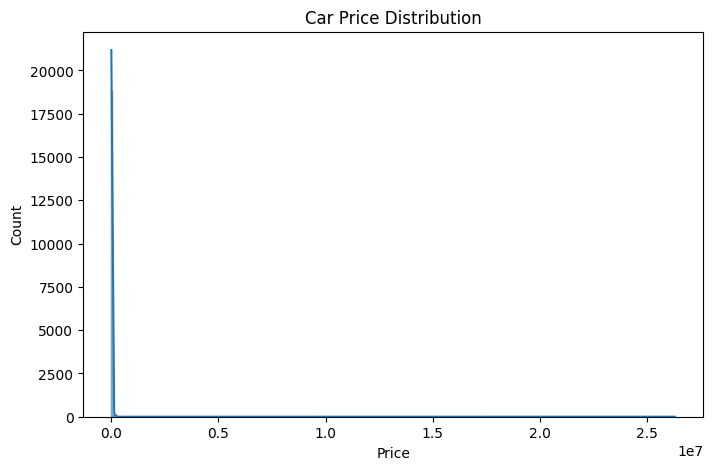

In [14]:
# Target distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], kde=True)

plt.title("Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [15]:
# Convert all categorical columns into one numeric column each
# This keeps the original 17 input columns.

for col in categorical_columns:
    df[col] = df[col].astype("category").cat.codes

df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399.0,32,1242,2010,4,1,2,3.5,186005,6.0,0,0,1,0,12,12
1,44731507,16621,1018.0,8,658,2011,4,0,5,3.0,192000,6.0,2,0,1,0,1,8
2,45774419,8467,781.0,21,684,2006,3,0,5,1.3,200000,4.0,3,1,1,1,1,2
3,45769185,3607,862.0,16,661,2011,4,1,2,2.5,168966,4.0,0,0,1,0,14,0
4,45809263,11726,446.0,21,684,2014,3,1,5,1.3,91901,4.0,0,1,1,0,12,4


In [16]:
# Check data types after conversion
df.info()

<class 'pandas.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18924 non-null  int64  
 1   Price             18924 non-null  int64  
 2   Levy              18924 non-null  float64
 3   Manufacturer      18924 non-null  int8   
 4   Model             18924 non-null  int16  
 5   Prod. year        18924 non-null  int64  
 6   Category          18924 non-null  int8   
 7   Leather interior  18924 non-null  int8   
 8   Fuel type         18924 non-null  int8   
 9   Engine volume     18924 non-null  float64
 10  Mileage           18924 non-null  int64  
 11  Cylinders         18924 non-null  float64
 12  Gear box type     18924 non-null  int8   
 13  Drive wheels      18924 non-null  int8   
 14  Doors             18924 non-null  int8   
 15  Wheel             18924 non-null  int8   
 16  Color             18924 non-null  int8   
 17  Airbags  

In [17]:
# 17 INPUT COLUMNS + 1 OUTPUT COLUMN

X = df.drop(columns=["Price"])
y = df["Price"]

print("Input shape :", X.shape)
print("Output shape:", y.shape)
print("Number of input features:", X.shape[1])

Input shape : (18924, 17)
Output shape: (18924,)
Number of input features: 17


In [18]:
# Confirm exactly 17 input features
assert X.shape[1] == 17, "Input features are not exactly 17!"

print("Confirmed: 17 input features and 1 output feature.")

Confirmed: 17 input features and 1 output feature.


In [19]:
# Train-test split
train_X, test_X, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print(train_X.shape)
print(train_y.shape)
print(test_X.shape)
print(test_y.shape)

(13246, 17)
(13246,)
(5678, 17)
(5678,)


In [20]:
# Feature scaling
scaler = StandardScaler()

train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

print("Scaled train shape:", train_X.shape)
print("Scaled test shape :", test_X.shape)

Scaled train shape: (13246, 17)
Scaled test shape : (5678, 17)


In [21]:
train_X.shape[1]

17

In [22]:
model = Sequential()
model.add(Dense(units = 17, kernel_initializer = 'uniform', activation = 'relu', input_dim = 17))
model.add(Dense(units = 14, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dense(units = 12, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dense(units = 8, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dense(units = 4, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))

C:\Users\Roshan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 17)                  │             306 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 14)                  │             252 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 12)                  │             180 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │              54 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │              28 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 17)                  │             306 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 14)                  │             252 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 12)                  │             180 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │              54 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │              28 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [26]:
train_X.shape

(13246, 17)

In [27]:
history = model.fit(train_X, train_y, batch_size = 10, epochs = 10,validation_split=0.10)

Epoch 1/10
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 1.6777e-04 - loss: -257037844480.0000 - val_accuracy: 0.0000e+00 - val_loss: -2069051473920.0000
Epoch 2/10
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.6777e-04 - loss: -41130368434176.0000 - val_accuracy: 0.0000e+00 - val_loss: -141023472779264.0000
Epoch 3/10
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.6777e-04 - loss: -625767675330560.0000 - val_accuracy: 0.0000e+00 - val_loss: -1410463636127744.0000
Epoch 4/10
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.6777e-04 - loss: -3648529889230848.0000 - val_accuracy: 0.0000e+00 - val_loss: -6488051148652544.0000
Epoch 5/10
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.6777e-04 - loss: -13463548873146368.0000 - val_accuracy: 0.0000e+00 - val_loss: -21227459248652288.0000
Epoch 6/10
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.6777e-04 - loss: -37632507742519296.0000 - val_accuracy: 0.0000e+00 - val_loss: -5404746043

In [28]:
# Evaluate the model
test_loss = model.evaluate(
    test_X,
    test_y,
    verbose=0
)

print(f"Test Mean Squared Error: {test_loss}")

Test Mean Squared Error: [-7.535477514756424e+17, 0.0]


In [29]:
prob_test=model.predict(test_X)  # Probability 

print(prob_test[:10])

178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


In [30]:
from sklearn import metrics
y_test_pred=np.where(prob_test>0.5,1,0)
print(metrics.classification_report(test_y, y_test_pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       4.0
           6       0.00      0.00      0.00       3.0
          20       0.00      0.00      0.00       1.0
          25       0.00      0.00      0.00       5.0
          28       0.00      0.00      0.00       1.0
          30       0.00      0.00      0.00      23.0
          31       0.00      0.00      0.00       4.0
          33       0.00      0.00      0.00       1.0
          34       0.00      0.00      0.00       1.0
          35       0.00      0.00      0.00       2.0
          40       0.00      0.00      0.00      12.0
          45       0.00      0.00      0.00       6.0
          47       0.00      0.00      0.00       1.0
          50       0.00      0.00      0.00       7.0
          60       0.00      0.00      0.00       7.0
          63       0.00      0.00      0.00       1.0
          69       0.00    

C:\Users\Roshan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Roshan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Roshan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

# Train the ANN
history = model.fit(
    train_X,
    train_y,
    epochs=50,
    batch_size=32,
    validation_split=0.10
)

In [31]:
# Evaluation metrics
y_pred = prob_test.flatten()

mae = mean_absolute_error(test_y, y_pred)
mse = mean_squared_error(test_y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 17031.001953125
MSE : 616289536.0
RMSE: 24825.179475685567
R2 Score: -0.8890998363494873


In [32]:
# Actual vs Predicted
result = pd.DataFrame({
    "Actual Price": test_y.values,
    "Predicted Price": y_pred
})

result.head(10)

,Actual Price,Predicted Price
0,11604,1.0
1,470,1.0
2,20162,1.0
3,7527,1.0
4,18817,1.0
5,44003,1.0
6,21326,1.0
7,15681,1.0
8,6899,1.0
9,1333,1.0


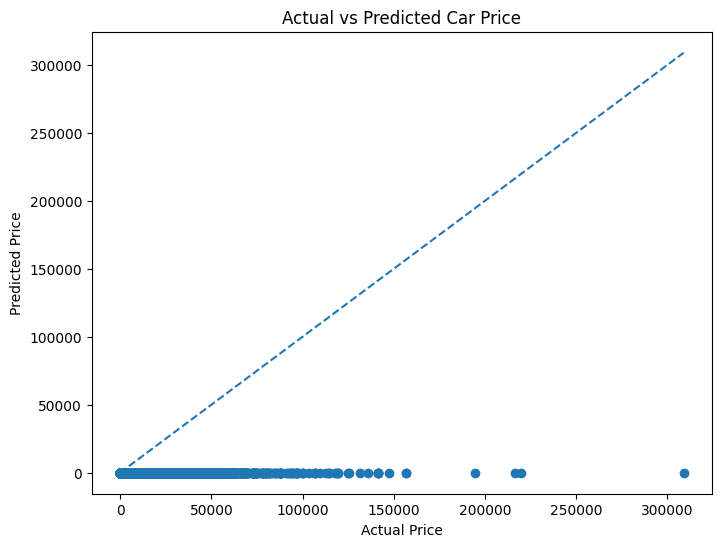

In [33]:
# Actual vs Predicted graph
plt.figure(figsize=(8, 6))

plt.scatter(test_y, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")

minimum = min(test_y.min(), y_pred.min())
maximum = max(test_y.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.show()

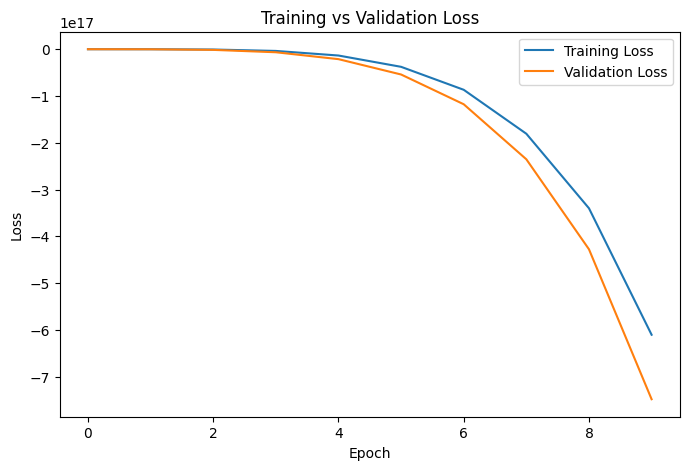

In [34]:
# Training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [35]:
# Save the model
model.save("car_price_model_17_features.keras")

print("Model saved successfully!")

Model saved successfully!


In [36]:
import joblib

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [37]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'Car_Price_ANN  rt.ipynb', 'Car_Price_ANN - Copy.ipynb', 'Car_Price_ANN.ipynb', 'car_price_model_17_features.keras', 'data', 'scaler.pkl']
